In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import tensorflow as tf
from datetime import datetime
pd.set_option('display.max_rows', None)

In [17]:
print(tf.config.list_physical_devices('GPU'))

[]


componentsA = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetA_components.csv')
eventsA = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetA_events.csv')
componentsB = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetB_components.csv')
eventsB = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetB_events.csv')
componentsC = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetC_components.csv')
eventsC = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetC_events.csv')
componentsD = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetD_components.csv')
eventsD = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetD_events.csv')


In [18]:
componentsA = pd.read_csv('data/SCLDDoS2024_SetA_components.csv')
eventsA = pd.read_csv('data/SCLDDoS2024_SetA_events.csv')
componentsB = pd.read_csv('data/SCLDDoS2024_SetB_components.csv')
eventsB = pd.read_csv('data/SCLDDoS2024_SetB_events.csv')
componentsC = pd.read_csv('data/SCLDDoS2024_SetC_components.csv')
eventsC = pd.read_csv('data/SCLDDoS2024_SetC_events.csv')
componentsD = pd.read_csv('data/SCLDDoS2024_SetD_components.csv')
eventsD = pd.read_csv('data/SCLDDoS2024_SetD_events.csv')

A = pd.merge(eventsA, componentsA, on='Attack ID')
B = pd.merge(eventsB, componentsB, on='Attack ID')
C = pd.merge(eventsC, componentsC, on='Attack ID')
D = pd.merge(eventsD, componentsD, on='Attack ID')

train = pd.concat([A, B])
test = C
val = D

In [19]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Transform 'Type' column
train['Type'] = le.fit_transform(train['Type'])
test['Type'] = le.fit_transform(test['Type'])
val['Type'] = le.fit_transform(val['Type'])
# Transform 'Attack code_x' column
train['Attack code_x'] = le.fit_transform(train['Attack code_x'])
test['Attack code_x'] = le.fit_transform(test['Attack code_x'])
val['Attack code_x'] = le.fit_transform(val['Attack code_x'])

In [20]:
def count_differences(df, col_x, col_y):
    return (df[col_x] != df[col_y]).sum() / len(df) * 100

columns_to_compare = [
    ('Significant flag_x', 'Significant flag_y'),
    ('Card_x', 'Card_y'),
    ('Victim IP_x', 'Victim IP_y'),
    ('Port number_x', 'Port number_y'),
    ('Attack code_x', 'Attack code_y'),
    ('Detect count_x', 'Detect count_y'),
    ('Packet speed_x', 'Packet speed_y'),
    ('Data speed_x', 'Data speed_y'),
    ('Avg packet len_x', 'Avg packet len_y')
]

for col_x, col_y in columns_to_compare:
    train[f'diff_{col_x}_{col_y}'] = count_differences(train, col_x, col_y)
    test[f'diff_{col_x}_{col_y}'] = count_differences(test, col_x, col_y)
    val[f'diff_{col_x}_{col_y}'] = count_differences(val, col_x, col_y)

train.head()

,Attack ID,Card_x,Victim IP_x,Port number_x,Attack code_x,Detect count_x,Significant flag_x,Packet speed_x,Data speed_x,Avg packet len_x,...,Time,diff_Significant flag_x_Significant flag_y,diff_Card_x_Card_y,diff_Victim IP_x_Victim IP_y,diff_Port number_x_Port number_y,diff_Attack code_x_Attack code_y,diff_Detect count_x_Detect count_y,diff_Packet speed_x_Packet speed_y,diff_Data speed_x_Data speed_y,diff_Avg packet len_x_Avg packet len_y
0,1,sga10gq0,IP_0001,4500,54,1,0,55600,73,1383,...,2022-08-08T18:09:36,17.333309,0.0,0.040547,37.746684,100.0,85.45298,90.960012,86.356177,49.504338
1,2,sga10gq0,IP_0002,4500,54,1,0,63500,90,1506,...,2022-08-08T18:37:28,17.333309,0.0,0.040547,37.746684,100.0,85.45298,90.960012,86.356177,49.504338
2,3,sga10gq0,IP_0003,1200,54,2,0,62700,82,1399,...,2022-08-08T18:41:25,17.333309,0.0,0.040547,37.746684,100.0,85.45298,90.960012,86.356177,49.504338
3,3,sga10gq0,IP_0003,1200,54,2,0,62700,82,1399,...,2022-08-08T18:41:26,17.333309,0.0,0.040547,37.746684,100.0,85.45298,90.960012,86.356177,49.504338
4,4,sga10gq0,IP_0002,4500,54,1,0,59500,85,1486,...,2022-08-08T18:47:49,17.333309,0.0,0.040547,37.746684,100.0,85.45298,90.960012,86.356177,49.504338


In [21]:
train.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)
test.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)
val.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)

In [22]:
num_cols = train.select_dtypes(include=[np.number]).columns
num_cols

Index(['Attack ID', 'Attack code_x', 'Avg source IP count', 'Type',
       'Detect count_y', 'Port number_y', 'Packet speed_y', 'Data speed_y',
       'Avg packet len_y', 'Source IP count',
       'diff_Significant flag_x_Significant flag_y', 'diff_Card_x_Card_y',
       'diff_Victim IP_x_Victim IP_y', 'diff_Port number_x_Port number_y',
       'diff_Attack code_x_Attack code_y',
       'diff_Detect count_x_Detect count_y',
       'diff_Packet speed_x_Packet speed_y', 'diff_Data speed_x_Data speed_y',
       'diff_Avg packet len_x_Avg packet len_y'],
      dtype='object')

for column in num_cols:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train[column])
plt.title(f'Boxplot for {column}')
plt.show()


In [23]:
train = train[train['End time'] != '0']
test = test[test['End time'] != '0']
val = val[val['End time'] != '0']

In [24]:
dataframes = {'train': train, 'test': test, 'val': val}

In [25]:
"""from sklearn.preprocessing import MultiLabelBinarizer

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    train[cat] = train[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(train[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    train = train.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    test[cat] = test[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(test[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    test = test.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    val[cat] = val[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(val[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    val = val.join(encoded_categories)
train.head()"""

"from sklearn.preprocessing import MultiLabelBinarizer\n\nfor cat in cat_cols:\n    # 🔹 Step 1: Convert comma-separated strings into lists\n    train[cat] = train[cat].apply(lambda x: x.split(','))\n\n    # 🔹 Step 2: Use MultiLabelBinarizer to encode\n    mlb = MultiLabelBinarizer()\n    encoded_categories = pd.DataFrame(mlb.fit_transform(train[cat]), columns=mlb.classes_)\n    encoded_categories = encoded_categories.add_prefix(f'{cat}_')\n\n    # 🔹 Step 3: Merge back with original DataFrame\n    train = train.join(encoded_categories)\n\nfor cat in cat_cols:\n    # 🔹 Step 1: Convert comma-separated strings into lists\n    test[cat] = test[cat].apply(lambda x: x.split(','))\n\n    # 🔹 Step 2: Use MultiLabelBinarizer to encode\n    mlb = MultiLabelBinarizer()\n    encoded_categories = pd.DataFrame(mlb.fit_transform(test[cat]), columns=mlb.classes_)\n    encoded_categories = encoded_categories.add_prefix(f'{cat}_')\n\n    # 🔹 Step 3: Merge back with original DataFrame\n    test = test.joi

In [26]:
import re
train['Victim IP_y'] = train['Victim IP_y'].apply(lambda x: int(re.search(r'\d+', x).group()))
test['Victim IP_y'] = test['Victim IP_y'].apply(lambda x: int(re.search(r'\d+', x).group()))
val['Victim IP_y'] = val['Victim IP_y'].apply(lambda x: int(re.search(r'\d+', x).group()))

C:\Users\Admin\AppData\Local\Temp\ipykernel_28084\2462103035.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['Victim IP_y'] = val['Victim IP_y'].apply(lambda x: int(re.search(r'\d+', x).group()))


In [27]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Packet speed_y', 'Data speed_y', 'Avg packet len_y']

scaler = MinMaxScaler()

train[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(train[columns_to_scale])
test[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(test[columns_to_scale])
val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])

C:\Users\Admin\AppData\Local\Temp\ipykernel_28084\725891811.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])
C:\Users\Admin\AppData\Local\Temp\ipykernel_28084\725891811.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])
C:\Users\Admin\AppData\Local\Temp\ipykernel_28084\725891811.py:9: SettingWithCopyWarni

In [28]:
train.columns

Index(['Attack ID', 'Attack code_x', 'Avg source IP count', 'Start time',
       'End time', 'Type', 'Detect count_y', 'Victim IP_y', 'Port number_y',
       'Attack code_y', 'Packet speed_y', 'Data speed_y', 'Avg packet len_y',
       'Source IP count', 'diff_Significant flag_x_Significant flag_y',
       'diff_Card_x_Card_y', 'diff_Victim IP_x_Victim IP_y',
       'diff_Port number_x_Port number_y', 'diff_Attack code_x_Attack code_y',
       'diff_Detect count_x_Detect count_y',
       'diff_Packet speed_x_Packet speed_y', 'diff_Data speed_x_Data speed_y',
       'diff_Avg packet len_x_Avg packet len_y', 'Packet speed_y_normalized',
       'Data speed_y_normalized', 'Avg packet len_y_normalized'],
      dtype='object')

In [29]:
# Drop columns starting with 'diff_'
train = train[[col for col in train.columns if not col.startswith('diff_')]]
test = test[[col for col in test.columns if not col.startswith('diff_')]]
val = val[[col for col in val.columns if not col.startswith('diff_')]]

In [30]:
train.to_parquet('data/trainprep.parquet', index=False)
test.to_parquet('data/testprep.parquet', index=False)
val.to_parquet('data/valprep.parquet', index=False)

In [27]:
train.columns

Index(['Attack ID', 'Attack code_x', 'Avg source IP count', 'Start time',
       'End time', 'Type', 'Detect count_y', 'Victim IP_y', 'Port number_y',
       'Attack code_y', 'Packet speed_y', 'Data speed_y', 'Avg packet len_y',
       'Source IP count', 'Packet speed_y_normalized',
       'Data speed_y_normalized', 'Avg packet len_y_normalized'],
      dtype='object')

In [28]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y',
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y',
       'Source IP count', 'Packet speed_y_normalized',
       'Data speed_y_normalized', 'Avg packet len_y_normalized']

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Initialize the Random Forest classifier
rfc = RandomForestClassifier(n_estimators=250, random_state=42, max_depth=10, verbose=1)

# Train the classifier on the SMOTE-augmented training data
rfc.fit(train[x_cols], train['Type'])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.6min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  6.6min


RandomForestClassifier(max_depth=10, n_estimators=250, random_state=42,
                       verbose=1)

In [30]:
# Predict the labels for the test data
test['pred'] = rfc.predict(test[x_cols])

# Evaluate the model
accuracy = accuracy_score(test['Type'], test['pred'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Type'], test['pred'], average='macro')
print("F1-Score:", f1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.9s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    8.0s
C:\Users\Admin\AppData\Local\Temp\ipykernel_14108\2650051780.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred'] = rfc.predict(test[x_cols])


Accuracy: 0.7755290371099669
Precision: 0.7946684088886186
Recall: 0.4477995910981814
F1-Score: 0.4845530867990296


In [31]:
feature_importances = pd.Series(rfc.feature_importances_, index=x_cols)
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
Avg source IP count            0.173795
Detect count_y                 0.138023
Victim IP_y                    0.117469
Source IP count                0.111773
Data speed_y_normalized        0.093404
Data speed_y                   0.086225
Port number_y                  0.083188
Avg packet len_y_normalized    0.058591
Avg packet len_y               0.052764
Packet speed_y                 0.043682
Packet speed_y_normalized      0.041087
dtype: float64


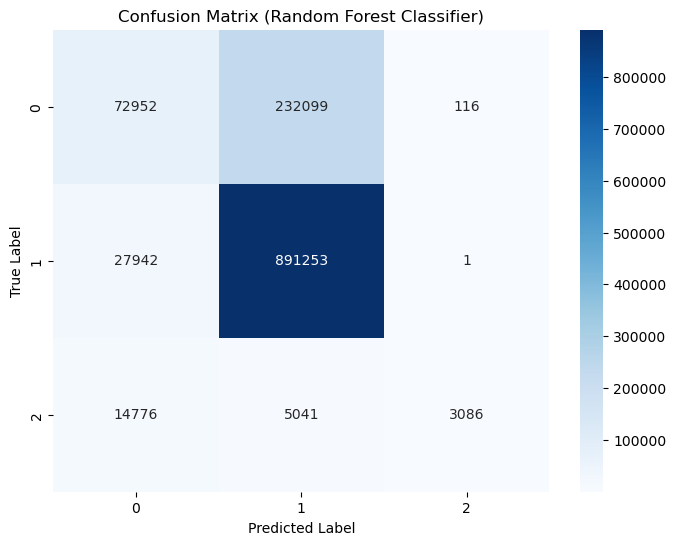

Confusion Matrix (Random Forest Classifier):
 [[ 72952 232099    116]
 [ 27942 891253      1]
 [ 14776   5041   3086]]


In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(test['Type'], test['pred'])

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(test['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [33]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(test['pred'], test['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.24      0.63      0.35    115670
           1       0.97      0.79      0.87   1128393
           2       0.13      0.96      0.24      3203

    accuracy                           0.78   1247266
   macro avg       0.45      0.79      0.48   1247266
weighted avg       0.90      0.78      0.82   1247266



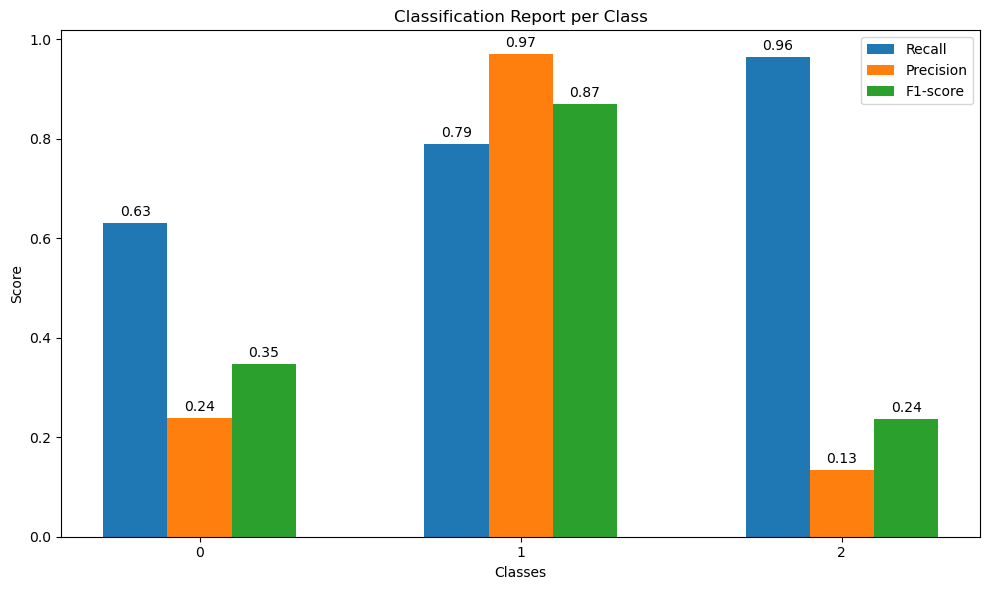

In [36]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the classification report as a dictionary
report = classification_report(test['Type'], test['pred'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()